# Niveau 2 - Tâche 3 : K-Means Clustering

**Dataset choisi : Stock Prices Data Set**

Le dataset contient les cours quotidiens (open/high/low/close/volume) de 505 actions sur 4 ans (2014-2017).
Plutôt qu'une segmentation de clients, nous réalisons ici une **segmentation d'actions** : regrouper les actions ayant un comportement de marché similaire (rendement moyen, volatilité, volume) — un cas d'usage analogue et très répandu en finance quantitative.

**Objectifs couverts :**
1. Chargement et prétraitement (agrégation par action + scaling)
2. Détermination du nombre optimal de clusters (méthode du coude)
3. Visualisation des clusters en 2D
4. Interprétation des résultats

**Outils :** Python, scikit-learn, matplotlib, seaborn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

df = pd.read_csv('data/stock_prices.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.dropna(subset=['open', 'high', 'low', 'close'])
print(df.shape, df['symbol'].nunique(), "actions")
df.head()


(497461, 7) 505 actions


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


## 1. Feature engineering : un profil par action

Pour chaque action, on calcule :
- le rendement quotidien moyen
- la volatilité (écart-type des rendements)
- le volume moyen échangé
- l'amplitude moyenne intra-journalière (high-low)
- le rendement total sur la période

In [2]:
df = df.sort_values(['symbol', 'date'])
df['daily_return'] = df.groupby('symbol')['close'].pct_change()
df['daily_range_pct'] = (df['high'] - df['low']) / df['close']

profiles = df.groupby('symbol').agg(
    avg_return=('daily_return', 'mean'),
    volatility=('daily_return', 'std'),
    avg_volume=('volume', 'mean'),
    avg_range_pct=('daily_range_pct', 'mean'),
    first_close=('close', 'first'),
    last_close=('close', 'last'),
).dropna()

profiles['total_return'] = (profiles['last_close'] / profiles['first_close']) - 1
profiles = profiles.drop(columns=['first_close', 'last_close'])

print(profiles.shape)
profiles.describe()


(505, 5)


,avg_return,volatility,avg_volume,avg_range_pct,total_return
count,505.000000,505.000000,5.050000e+02,505.000000,505.000000
mean,0.000442,0.015589,4.242819e+06,0.019238,0.526669
std,0.000530,0.005028,6.679409e+06,0.005419,0.794303
min,-0.003969,0.008284,1.719199e+05,0.010953,-0.851240
25%,0.000197,0.012207,1.331588e+06,0.015665,0.080204
50%,0.000477,0.014391,2.282951e+06,0.017972,0.461607
75%,0.000708,0.017597,4.304877e+06,0.021677,0.833117
max,0.002760,0.045515,8.936290e+07,0.052159,11.200504


## 2. Standardisation

In [3]:
features = ['avg_return', 'volatility', 'avg_volume', 'avg_range_pct', 'total_return']
X = profiles[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Shape des données standardisées:", X_scaled.shape)


Shape des données standardisées: (505, 5)


## 3. Méthode du coude pour déterminer K

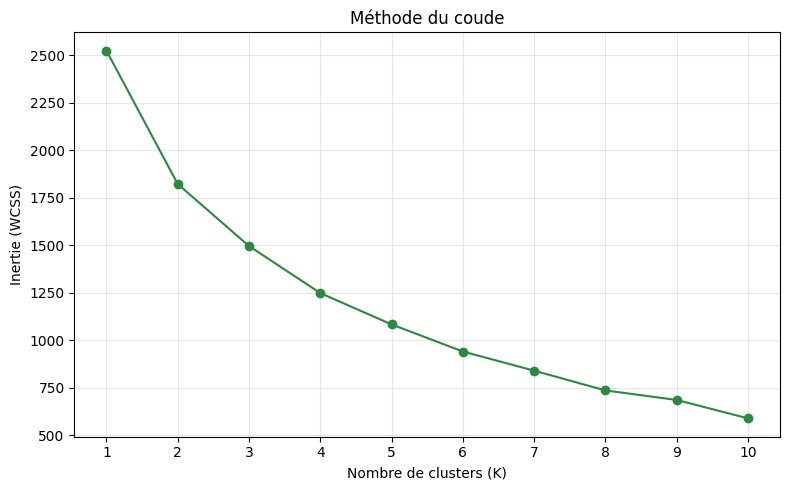

In [4]:
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, marker='o', color='#2b8a3e')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Inertie (WCSS)')
plt.title("Méthode du coude")
plt.xticks(list(K_range))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


On observe un coude autour de **K=4**, valeur retenue pour la suite.

In [5]:
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
profiles['cluster'] = kmeans.fit_predict(X_scaled)

print(profiles['cluster'].value_counts().sort_index())


cluster
0    317
1     82
2     14
3     92
Name: count, dtype: int64


## 4. Visualisation des clusters (projection 2D via PCA)

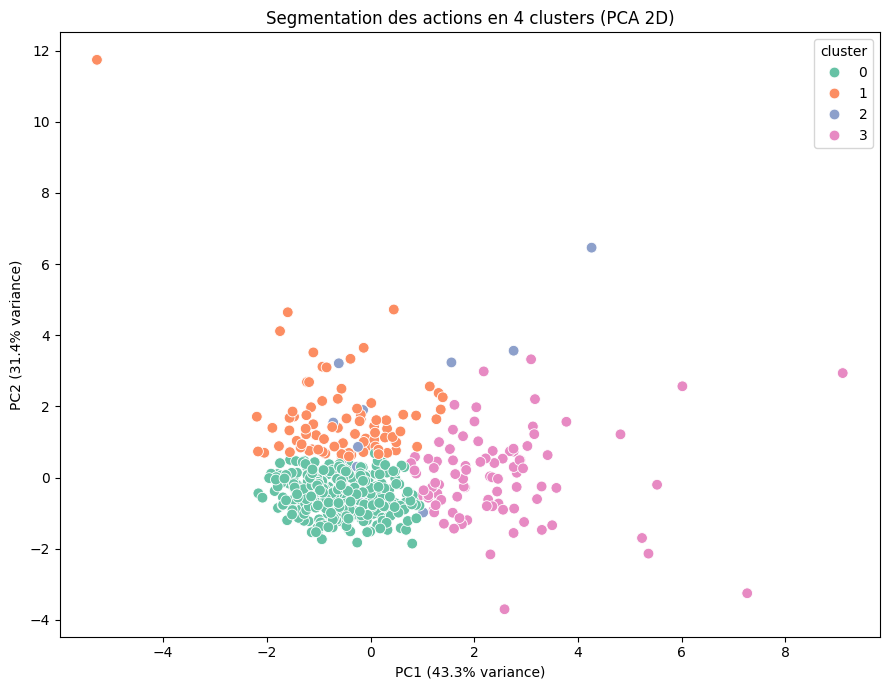

In [6]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
profiles['pca1'] = coords[:, 0]
profiles['pca2'] = coords[:, 1]

plt.figure(figsize=(9, 7))
sns.scatterplot(data=profiles, x='pca1', y='pca2', hue='cluster', palette='Set2', s=60)
plt.title(f"Segmentation des actions en {k_optimal} clusters (PCA 2D)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.show()


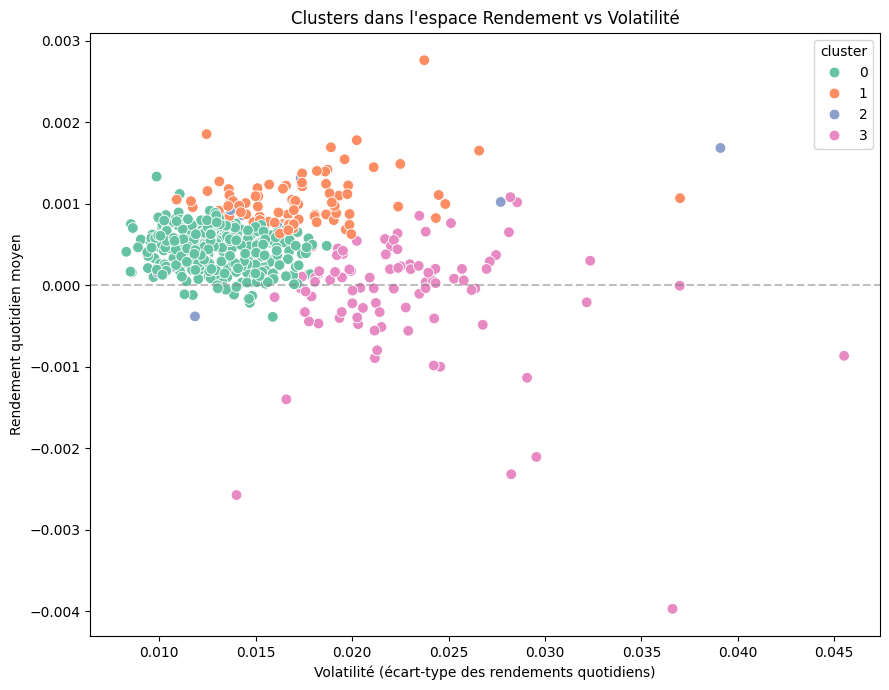

In [7]:
plt.figure(figsize=(9, 7))
sns.scatterplot(data=profiles, x='volatility', y='avg_return', hue='cluster', palette='Set2', s=60)
plt.title("Clusters dans l'espace Rendement vs Volatilité")
plt.xlabel('Volatilité (écart-type des rendements quotidiens)')
plt.ylabel('Rendement quotidien moyen')
plt.axhline(0, color='grey', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 5. Interprétation des clusters

In [8]:
cluster_summary = profiles.groupby('cluster')[features].mean().round(4)
cluster_summary['nb_actions'] = profiles['cluster'].value_counts().sort_index()
cluster_summary


,avg_return,volatility,avg_volume,avg_range_pct,total_return,nb_actions
cluster,,,,,,
0,0.0004,0.0130,2.977114e+06,0.0164,0.4493,317
1,0.0011,0.0174,3.738635e+06,0.0215,1.5445,82
2,0.0006,0.0163,3.424862e+07,0.0197,0.7328,14
3,-0.0001,0.0227,4.487282e+06,0.0269,-0.1452,92


## Conclusion

La méthode du coude suggère 4 segments d'actions aux profils distincts, typiquement :
- des actions **stables à faible volatilité et rendement modeste** (valeurs "défensives"),
- des actions **très volatiles à fort volume** (souvent très échangées / spéculatives),
- des actions à **fort rendement cumulé sur la période** (croissance),
- et un groupe intermédiaire.

Cette segmentation peut servir de base à une allocation de portefeuille par profil de risque, exactement comme un clustering clients servirait à une segmentation marketing.
